# Comprensión y Análisis Exploratorio de Datos (EDA)

En esta etapa se realiza una exploración inicial del dataset con el fin de comprender la estructura de la información, identificar valores faltantes, analizar la variable objetivo y detectar posibles oportunidades de mejora para el modelado posterior.

In [2]:
#Cargar librerias
from cargar_datos import cargarDatos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = cargarDatos()
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


In [3]:
#DIMENSIONES DEL DATASET
print("Dimensiones del dataset:", df.shape)

Dimensiones del dataset: (10763, 23)


In [4]:
#TIPOS DE DATOS Y ESTRUCTURA
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[us]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  str           
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvigentes     

#Estructura general del dataset

Se observa un conjunto de variables numéricas y categóricas relacionadas con características crediticias, laborales, historial financiero e ingresos de los clientes.

La variable objetivo es **Pago_atiempo**, donde:

- 1 = paga a tiempo  
- 0 = no paga a tiempo

In [5]:
#Valores nulos
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

print(nulos)

tendencia_ingresos               2932
promedio_ingresos_datacredito    2930
saldo_mora_codeudor               590
saldo_principal                   405
saldo_mora                        156
saldo_total                       156
puntaje_datacredito                 6
dtype: int64


In [6]:
#Porcentaje de nulos
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
porcentaje_nulos = porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False)

print(porcentaje_nulos)

tendencia_ingresos               27.241475
promedio_ingresos_datacredito    27.222893
saldo_mora_codeudor               5.481743
saldo_principal                   3.762891
saldo_mora                        1.449410
saldo_total                       1.449410
puntaje_datacredito               0.055747
dtype: float64


#Valores faltantes

Se identifican valores faltantes en variables asociadas a saldos, comportamiento crediticio e ingresos. Estos valores serán tratados posteriormente mediante técnicas de imputación dentro del pipeline de preprocesamiento.

In [7]:
#Distribución variable objetivo
df["Pago_atiempo"].value_counts()

Pago_atiempo
1    10252
0      511
Name: count, dtype: int64

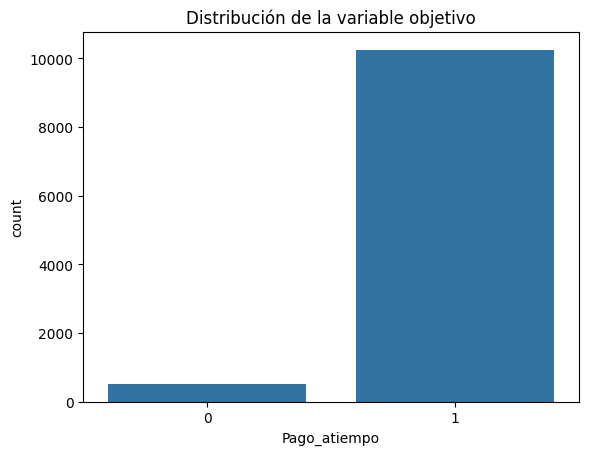

In [8]:
#Gráfico target
sns.countplot(data=df, x="Pago_atiempo")
plt.title("Distribución de la variable objetivo")
plt.show()

#Desbalance de clases

Se evidencia un fuerte desbalance en la variable objetivo, donde predominan ampliamente los clientes que sí pagan a tiempo.
Esto representa un reto para el modelado supervisado, especialmente para detectar correctamente la clase minoritaria (clientes morosos).

In [9]:
#Tipo Credito
df["tipo_credito"].value_counts()

tipo_credito
4     7747
9     2876
10     116
6       21
7        2
68       1
Name: count, dtype: int64

In [10]:
#Tendencia ingresos
df["tendencia_ingresos"].value_counts(dropna=False)

tendencia_ingresos
Creciente      5294
NaN            2932
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
158042            1
3978              1
168750            1
-28589            1
-566272           1
24702             1
31837             1
122727            1
417087            1
9090              1
173031            1
-70715            1
-435177           1
-702927           1
-4105             1
54683             1
22832             1
209090            1
5697              1
10808             1
-288              1
-164315           1
2029000           1
17181             1
15245             1
82657             1
52862             1
1817052           1
75761             1
146918            1
1123000           1
15090             1
4250635           1
22363             1
-101368           1
86286             1
65988             1
77975             1
-224714           1
Name: count, dtype: int64

#Calidad de variables categóricas

Se detectaron categorías inconsistentes o registros atípicos en algunas variables como:
-tipo_credito
-tendencia_ingresos

Por ello, posteriormente se realizó limpieza y recodificación durante la etapa de feature engineering.

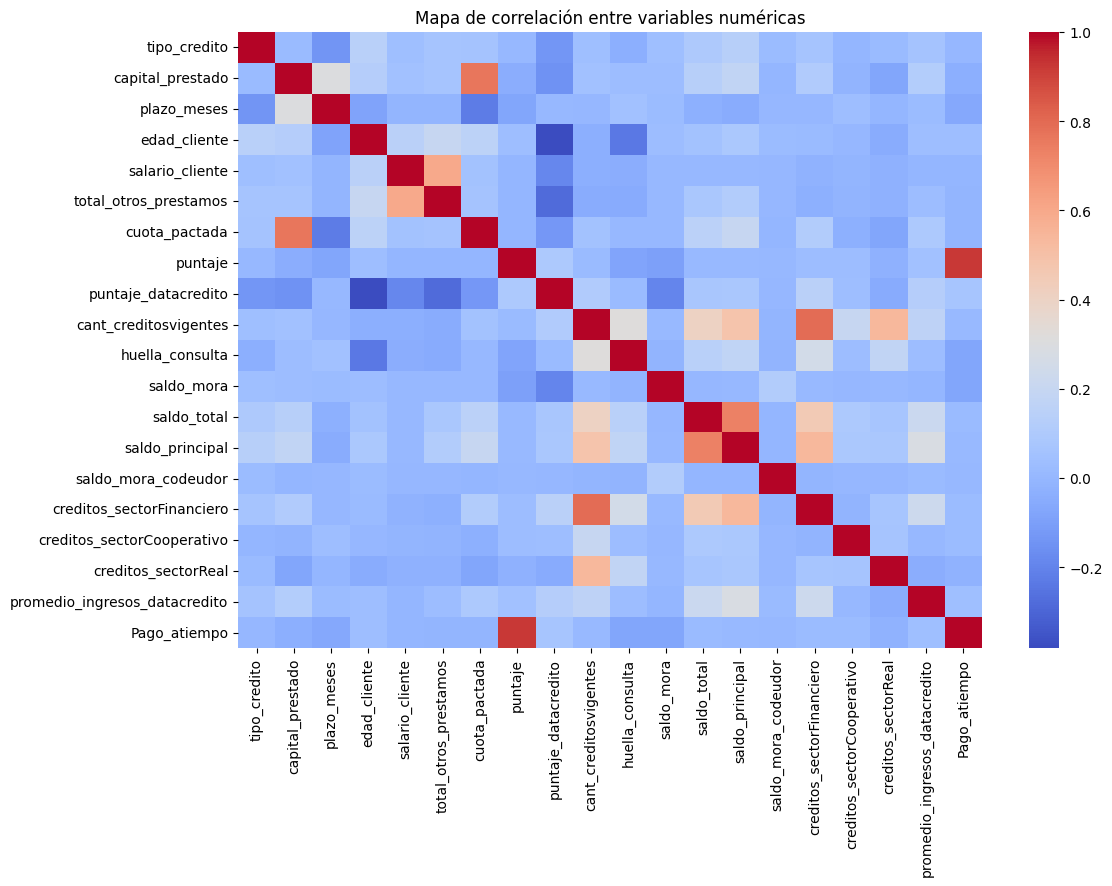

In [11]:
#Correlaciones numéricas
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=["int64","float64"]).corr(), cmap="coolwarm")
plt.title("Mapa de correlación entre variables numéricas")
plt.show()

In [12]:
#Indagación de posible data leakage
df[["Pago_atiempo","puntaje","puntaje_datacredito"]].corr()

,Pago_atiempo,puntaje,puntaje_datacredito
Pago_atiempo,1.000000,0.923134,0.067882
puntaje,0.923134,1.000000,0.090551
puntaje_datacredito,0.067882,0.090551,1.000000


#Detección de posible data leakage

La variable "puntaje" mostró una correlación extremadamente alta con la variable objetivo.

Esto sugiere que podría contener información calculada posterior al evento de pago, por lo que fue excluida del modelado para evitar fugas de información (*data leakage*).

CONCLUSIONES

Principales hallazgos:

- Existe desbalance importante de clases.
- Se identificaron valores faltantes.
- Algunas variables requieren limpieza y recategorización.
- Se detectó posible leakage en la variable puntaje. EN los modelos entrenados preliminarmente, esto se corroboró pues las métricas de desempeño daban casi perfectas, lo cual no es un resultado muy realista. 
- El dataset contiene información suficiente para desarrollar modelos predictivos con preprocesamiento adecuado.